In [105]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
df = pd.read_csv("Kodlarım/Python/datasets/ML Datasets/1-studyhours.csv")

In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Study Hours  33 non-null     float64
 1   Exam Score   33 non-null     float64
dtypes: float64(2)
memory usage: 660.0 bytes


In [108]:
df.describe()

,Study Hours,Exam Score
count,33.000000,33.000000
mean,15.772727,74.612121
std,7.608723,18.711206
min,3.000000,40.000000
25%,9.600000,58.500000
50%,17.400000,78.800000
75%,21.300000,90.800000
max,30.000000,100.000000


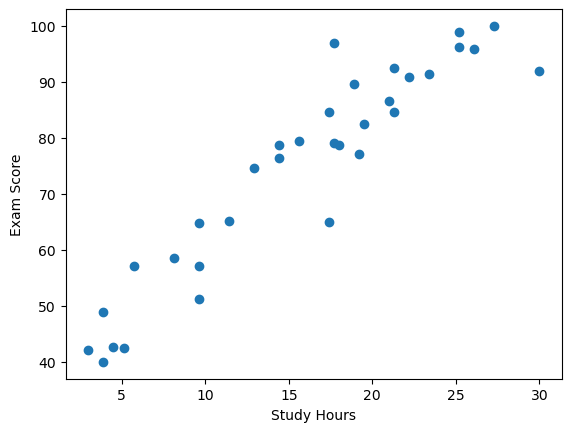

In [109]:
plt.scatter(df["Study Hours"], df["Exam Score"])
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.show()

# y değişkeninde hedef değişken olur genelde

##### İndependent and Dependent Features

-- X featureslar olur ve büyük yazılır <p>
-- y hedef değişkendir ve küçük yazılır. <p>
-- X'ler genelde dataframe olunmasını talep eder, çünkü birden fazla geleceğini varsayar. <p>
-- y değerlerinde ise tek bir çıktı olacağından dolayı seriesi kabul eder. <p>

In [110]:
X = df[["Study Hours"]]
y = df["Exam Score"]

In [111]:
type(X)

pandas.core.frame.DataFrame

In [112]:
type(y)

pandas.core.series.Series

##### Test - Train Split

-- Bir model oluştururken dataset 2'ye ayırılır. <p>

    -- Bir kısım train yani eğitim seti olur, model oluşturulur. <p>
    -- Diğer bir kısım ise test yani eğitim seti olur, model test edilir. <p>

-- Yani grafiğe çizgiyi çizerken, 33 tane verinin 10 tanesi test, 23 tanesi ise eğitim seti olacağını varsayalım;

    -- Bu durumda model öncelikle 23 çizgi etrafına çizgiyi çizecek, daha sonrasında 10 tane test seti ile çizgiye yakınlık ve uzaklığına bakarak target değişkenin gerçeğe ne kadar yakınasdığını veya uzaksadığını bulacağız. Böylelikle model başarılı mı değil mi bunu anlamış olacağız. y tahmin - y gerçek

-- Bu ayırma işlemi için sklearn kütüphanesi mevcut:

    -- from sklearn.model_selection import train_test_split
    -- train_test_split ile aşağıdaki metodlar ortaya çıkar:

        -- train_size --> modelin % kaçı train'e sokulsun? 0-1 arası bir sayı verilir. genelde belirtilmez, sadece test verilir. kalanı train içindir. 

        -- test_size --> modelin % kaçı teste sokulsun? 0-1 arası bir sayı verilir.
            --genelde %20 - %33 - 35 arası bir size verilir. datasetin büyüklüğüne göre değişir.

        -- random_state --> herhangi bir sayı verilir, kendi içinde rastgele veri seçilir. 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.33, random_state = 42)

In [113]:
from sklearn.model_selection import train_test_split

In [114]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state=15
)

""" 
X'i 2'ye böldü --> %80 eğitim yani train, %20 test
y'yi 2'ye böldü --> %80 eğitim yani train, %20 test
"""

" \nX'i 2'ye böldü --> %80 eğitim yani train, %20 test\ny'yi 2'ye böldü --> %80 eğitim yani train, %20 test\n"

In [115]:
y_train

18     64.9
1      57.1
2      42.7
32     89.6
6      77.1
3      65.1
29     82.4
26     64.8
9      84.6
4      78.7
28     79.1
10     92.4
27     79.5
13    100.0
17     74.7
15     97.0
22     76.5
31     96.2
11     95.9
7      90.8
0      40.0
23     42.2
5      78.8
12     92.0
21     58.5
8      99.0
Name: Exam Score, dtype: float64

In [116]:
y_test

25    42.4
14    86.6
30    91.5
16    57.2
24    51.2
20    49.0
19    84.7
Name: Exam Score, dtype: float64

In [117]:
df

,Study Hours,Exam Score
0,3.9,40.0
1,9.6,57.1
2,4.5,42.7
3,11.4,65.1
4,14.4,78.7
5,18.0,78.8
6,19.2,77.1
7,22.2,90.8
8,25.2,99.0
9,17.4,84.6


##### Standardization

from sklearn.preprocessing import StandardScaler 

-- Train veya test verilerini küçültüp standart hale getirmek için kullanılır <p>

    -- Örneğin veride çok fazla kolon olabilir, örnek kolonlar aşağıdaki gibi; 

        -- Ev datası düşünelim;
            -- Evin m^2, loksayonu, kaç senelik olduğu, kaç yaşında olduğu 

        -- Yani çok fazla alanda ve birimde çok fazle veri olabilir. Örneğin m'2 90-100 gibi olabilirken, evin yaşını 0-40 civarı olabilir. Dolayısıyla elma ile armut karşılaştırmaya çalışabiliriz.
        Yani çok büyük olanlara daha büyük katsayı verilebilir, küçüklere küçük katsayı verebiliriz, bunu engellemek için standardization kullanılır. Böylelikle tüm kolonlarda yer alan değerler benzer sayılara sahip olur.

-- Özellikle mesafe tabanlı tahminleme modellerinde (SVM, yapay sinir ağları, KNN) doğru çalışması için kritik öneme sahiptir. <p>

-- Gradient Descent kullanan modellerin minimum hata noktasına çok daha hızlı ulaşmasını sağlar. <p>

-- Uç değerlere karşı daha dayanıklıdır; çünkü tüm veriyi 0-1 (MinMaxScalerv (Normalization) yapıyor bu işlemi) gibi kısıtlı bir aralığa sıkıştırmak yerine istatiksel bir dağılım oluşturur.<p>

-- Verinin ortalamasını 0, varyansını 1 yapacak şekilde ölçeklendirir. Dolayısıyla outlier değerlerden az etkileniyor.<p>

-- 2 Önemli fonksiyonu mevcut:

    -- .fit_transform() (sadece train datasında uygulanır!!!)
        -- Formül şu şekilde --> X değeri - X değerinin dataset ort. / X değerinin STD'si
    
    --.transform() (sadece teste uygulanır) # data leake olmaması için fit_transform kullanılmaz

##### Normalization <p>

-- Genellikle 0-1 arasına sıkıştırır. <p>

-- Uç değerlere karşı çok daha hassas, tek bir hatalı büyük değer diğer tüm verilerin çok dar bir aralıkta ezilmesine neden olabilir. <p>

-- Verinin tam sınırlarını korumak istendiğinde tercih edilir. <p>

-- Tüm bu yapılanlarla beraber:
    
    -- Data set daha dengeli bir hale gelir (balanced feature values)
    -- gradient descent'in verimlilği artar
    -- l1, l2 burda da verimlilik olur. 


In [118]:
df.head()

,Study Hours,Exam Score
0,3.9,40.0
1,9.6,57.1
2,4.5,42.7
3,11.4,65.1
4,14.4,78.7


In [119]:
from sklearn.preprocessing import StandardScaler 


In [120]:
scaler = StandardScaler()

In [121]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [122]:
X_train

array([[ 0.11794385],
       [-0.97424848],
       [-1.68837424],
       [ 0.32798083],
       [ 0.36998823],
       [-0.7222041 ],
       [ 0.41199563],
       [-0.97424848],
       [ 0.11794385],
       [-0.30213013],
       [ 0.15995124],
       [ 0.66404001],
       [-0.13410054],
       [ 1.50418796],
       [-0.51216711],
       [ 0.15995124],
       [-0.30213013],
       [ 1.21013618],
       [ 1.33615837],
       [ 0.7900622 ],
       [-1.77238903],
       [-1.89841122],
       [ 0.20195864],
       [ 1.88225453],
       [-1.18428547],
       [ 1.21013618]])

In [ ]:
işşlişkllöç.öç.öçm..÷

In [123]:
X_test

array([[-1.60435944],
       [ 0.62203261],
       [ 0.95809179],
       [-1.52034465],
       [-0.97424848],
       [-1.77238903],
       [ 0.66404001]])

In [124]:
from sklearn.linear_model import LinearRegression

In [125]:
regression = LinearRegression()

# n_jobs metodu: eğer bir model çok yavaş çalışıyorsa bunu -1 ver.

In [126]:
regression.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [127]:
print("Coefficient: ", regression.coef_)
print("Intercept: ", regression.intercept_)

# yani denklem şu: y = 71.58 + 17.77 x 
# açıklama: x standadscale edilmiş hali ancak şöyle okunabilir: hiç çalışmazsam 71.58, 1 saat çalışırsam 90 civarlırım.

Coefficient:  [16.17860223]
Intercept:  76.9076923076923


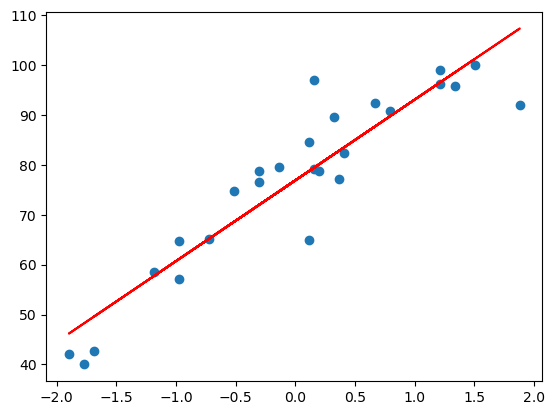

In [128]:
plt.scatter(X_train, y_train)
plt.plot(X_train, regression.predict(X_train), "r")
plt.show()

In [129]:
# 20 saat çalışan biri kaç alır? x=20, y=?

In [130]:
regression.predict([[20]])

array([400.47973694])

In [131]:
# 20'nin standardscale edilmiş halini bulmak için scaler.transform([[20]])

In [132]:
scaler.transform([[20]])

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.48200796]])

In [133]:
regression.predict([[0.63591611]])

array([87.1959261])

In [134]:
# yani 20 saat çalışan biri 82 alıyor.
# 15 saat çalışan 71 alıyor.

In [135]:
regression.predict(scaler.transform([[15]]))

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([73.37889111])

In [136]:
# prediction with test data

In [137]:
y_pred_test = regression.predict(X_test) #bunlar bizim tahminimiz

In [138]:
y_test # bu da gerçekler

25    42.4
14    86.6
30    91.5
16    57.2
24    51.2
20    49.0
19    84.7
Name: Exam Score, dtype: float64

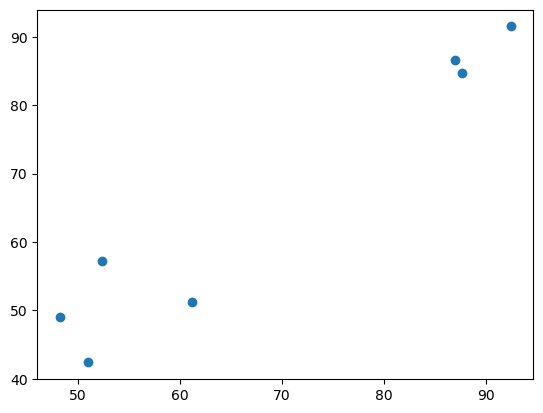

In [139]:
plt.scatter(y_pred_test, y_test)
plt.show()

In [140]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [141]:
mse = mean_squared_error(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
print("mse: ", mse)
print("mae: ", mae)
print("rmse: ", rmse)

mse:  29.45839048833392
mae:  4.054868128856142
rmse:  5.427558427906043


In [142]:
r2 = r2_score(y_test, y_pred_test)
print("r2 score: ", r2)

r2 score:  0.9196596206825491


In [143]:
# adjusted r2 score
1 - (1-r2)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.903591544819059